# 04 — Modelando o Peso

Aqui eu treino o modelo e testo a minha hipótese: se o peso depende tanto do tempo e da
ração acumulada, um modelo deveria prever bem.

Uma decisão importante que eu trouxe do meu estudo sobre validação: usei **GroupKFold por
viveiro**. Isso quer dizer que, quando testo o modelo, os cultivos de um viveiro ficam ou
todos no treino ou todos no teste, nunca divididos. Se eu não fizesse isso, o modelo
poderia "decorar" um viveiro e a métrica ficaria enganosamente boa. Agrupando por viveiro
eu garanto que ele é sempre testado em viveiros que nunca viu, que é o cenário real.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100; plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.3

In [2]:
from src.modelo_peso import carregar, avaliar_um
from sklearn.ensemble import RandomForestRegressor
df, feats = carregar()
print(f"{len(df)} biometrias | features: {feats}")

2072 biometrias | features: ['DIAS', 'RACAO_ACUM', 'RACAO_ACUM_POR_PL', 'DENSIDADE_PL_M2', 'SUP_05', 'TEMP_05', 'PH_05', 'SAL_14']


## Treinando e avaliando

Rodo o Random Forest com a validação por viveiro e vejo as métricas: MAE (erro médio em
gramas), RMSE (que penaliza erros grandes) e R² (o quanto da variação do peso o modelo
explica).

In [3]:
mae, rmse, r2 = avaliar_um(df, feats,
    RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42), False)
print(f"Random Forest -> MAE {mae:.2f}g | RMSE {rmse:.2f}g | R² {r2:.3f}")

Random Forest -> MAE 2.41g | RMSE 3.63g | R² 0.682


## Previsto × real

Pra ver a qualidade na prática, comparo o peso previsto com o real (usando previsões de
validação cruzada, então cada ponto foi previsto por um modelo que não o viu no treino).
Quanto mais perto da diagonal, melhor.

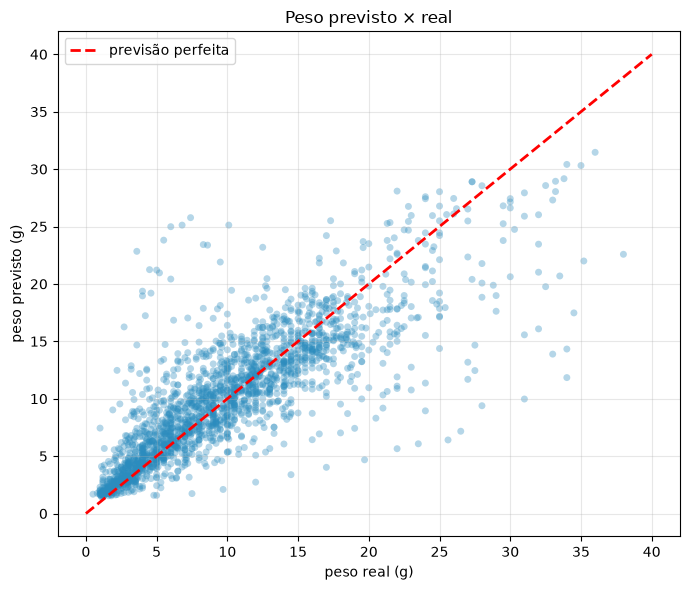

In [4]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
d = df.dropna(subset=["PESO"])
X,y,g = d[feats], d["PESO"], d["VIVEIRO"]
pipe = Pipeline([("i",SimpleImputer(strategy="median")),
                 ("rf",RandomForestRegressor(n_estimators=300,max_depth=8,min_samples_leaf=3,random_state=42))])
pred = cross_val_predict(pipe, X, y, groups=g, cv=GroupKFold(5))
plt.figure(figsize=(7,6))
plt.scatter(y, pred, alpha=0.35, color="#2b8cbe", edgecolor="none", s=25)
plt.plot([0,40],[0,40],"r--",lw=2,label="previsão perfeita")
plt.xlabel("peso real (g)"); plt.ylabel("peso previsto (g)")
plt.title("Peso previsto × real"); plt.legend(); plt.tight_layout(); plt.show()

O R² em torno de 0,68 mostra que o modelo explica boa parte da variação do peso.

**Próximo (05):** comparo vários modelos pra justificar a escolha.